In [1]:
# ============================================================
# COACH — Session Start  (do not remove this cell)
# ============================================================
import sys, os
sys.path.insert(0, os.path.expanduser('~/Desktop/applied-ai-research'))
from coach.notebook_widgets import render_session_start
_SESSION = render_session_start(
    module_id="rnn",
    notebook_name="04_gru.ipynb"
)

# GRU (Gated Recurrent Unit) -- A Simpler Alternative to LSTM

Welcome back. In the last notebook, you learned about LSTMs -- powerful gated RNNs with 3 gates and a separate cell state that solve the vanishing gradient problem. But all that machinery costs something: lots of parameters and slower training.

What if you could get **most of the benefits of LSTM with a simpler design**? That is exactly what the **GRU (Gated Recurrent Unit)** does.

Think of it this way. An LSTM is like a mixing board with a dozen knobs and sliders -- you can control everything, but it takes a while to learn. A GRU is the same board trimmed down to two controls: a **crossfader** and a **fresh-start button**. Fewer moving parts, but you can still make great music.

## What You Will Learn

By the end of this notebook, you will understand:
- Why GRU was invented (simplifying LSTM)
- The **two gates**: Update Gate and Reset Gate
- How to **build a GRU cell from scratch** with NumPy
- A step-by-step walkthrough of GRU processing a sequence
- **GRU vs LSTM**: parameter counts, equations, and when to use which
- How to **visualize gate activations** over a sequence
- A practical sequence prediction example

**Prerequisites:** Basic understanding of RNNs and the vanishing gradient problem. Familiarity with LSTM concepts is helpful but not required.

---

## Jargon Buster

| Term | Plain English Explanation |
|------|---------------------------|
| **GRU** | Gated Recurrent Unit -- a simplified version of LSTM with 2 gates instead of 3 |
| **Update Gate** | Like a DJ's crossfader: one knob controls the blend between the old memory and the new information. Slide left for more old, slide right for more new. |
| **Reset Gate** | Like a fresh-start button: press it to throw out your previous work and build the candidate from scratch |
| **Candidate Hidden State** | A proposed new hidden state, computed using the reset gate to selectively ignore parts of the old state |
| **Hidden State** | The GRU's memory at each time step -- unlike LSTM, there is NO separate cell state |
| **Sigmoid** | A function that squashes any number into the range (0, 1) -- perfect for gates that need to say "how much" |
| **Tanh** | A function that squashes any number into the range (-1, 1) -- used for the candidate hidden state |
| **Cell State** | LSTM's separate long-term memory highway -- GRU does NOT have this; it uses only the hidden state |
| **Parameter Count** | The total number of learnable weights in a model -- fewer parameters means faster training |

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline

np.random.seed(42)

print("✅ Libraries imported successfully!")
print("📦 NumPy version:", np.__version__)

✅ Libraries imported successfully!
📦 NumPy version: 1.26.4


---

## Part 1: From LSTM to GRU -- Why Simplify?

### The Moving Analogy

Imagine you are moving to a new apartment.

The **LSTM approach** is like hiring a full moving crew:

- **Forget Gate**: One person goes through ALL your old stuff and decides what to throw away.
- **Input Gate**: Another person decides which NEW items to bring in.
- **Output Gate**: A third person decides which items to put on display vs. keep in storage.
- **Cell State**: A big storage room, separate from the living area.

That is **3 people** and **2 rooms** (cell state + hidden state). It works great, but it is expensive.

The **GRU approach** is like doing it yourself with a simple rule:

- **Update Gate**: You alone decide the split. "How much old stuff do I keep, and how much new stuff do I add?" If you keep 70% old, you add 30% new. One knob, one decision.
- **Reset Gate**: Before looking at new stuff, you ask: "How much of my old stuff is even relevant right now?" If none of it matters, you hit the fresh-start button and evaluate everything with fresh eyes.
- **No separate storage room**: Everything lives in ONE place (just the hidden state).

That is **2 people** and **1 room**. Simpler, cheaper, and often just as effective.

### Key Differences at a Glance

| Feature | LSTM | GRU |
|---------|------|-----|
| Number of gates | 3 (forget, input, output) | 2 (update, reset) |
| Separate cell state? | Yes (cell state + hidden state) | No (hidden state only) |
| Parameters | More (~33% more than GRU) | Fewer |
| Training speed | Slower | Faster |
| Performance | Often slightly better on complex tasks | Comparable on many tasks |

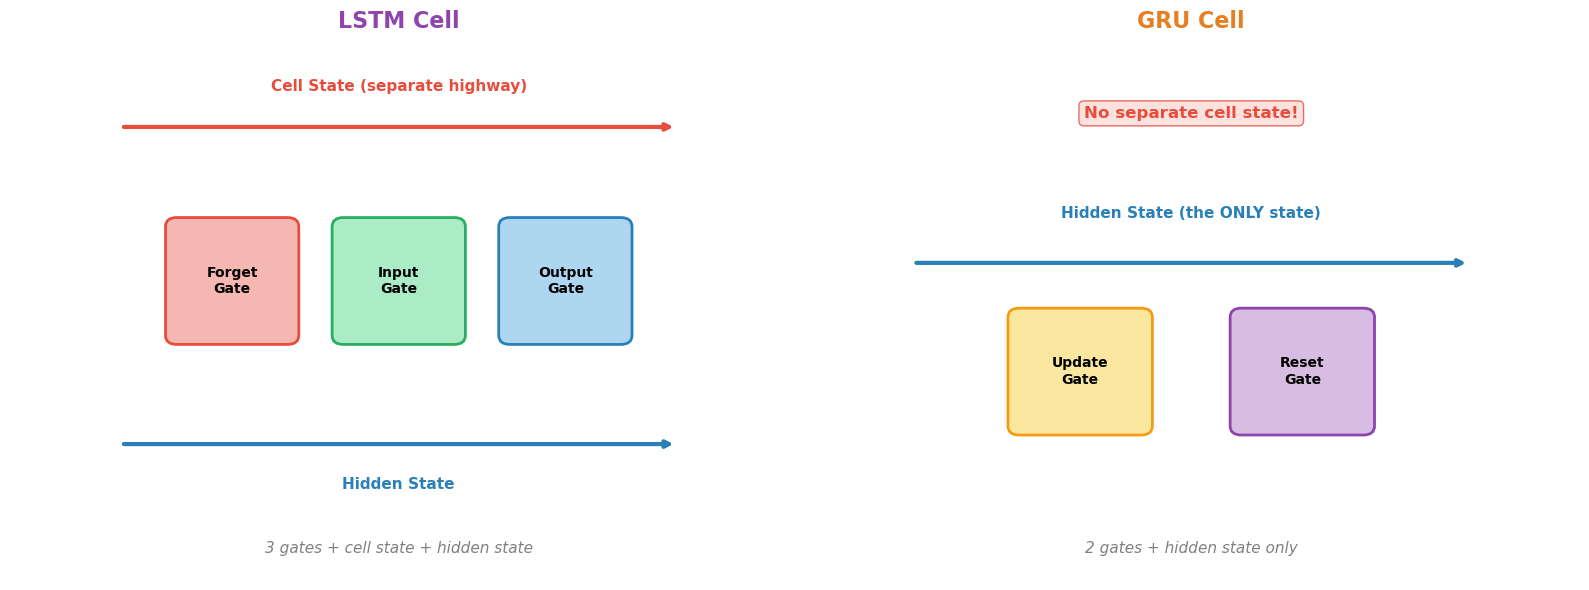

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/jupyter_client/session.py", line 100, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 560, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel/iostream.py", line 170, in _handle_event
    event_f()
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel/iostream.py", line 649, in _flush
    self.session.send(
  File "/opt/anaconda3/lib/python3.11/site-packages/jupyter_client/session.py", line 8

In [3]:
# Let's visualize the structural difference between LSTM and GRU

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LSTM Diagram ---
ax = axes[0]
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.5, 5.5)
ax.axis('off')
ax.set_title('LSTM Cell', fontsize=16, fontweight='bold', color='#8E44AD')

# Cell state highway
ax.annotate('', xy=(5.5, 4.5), xytext=(0.5, 4.5),
            arrowprops=dict(arrowstyle='->', lw=3, color='#E74C3C'))
ax.text(3.0, 4.9, 'Cell State (separate highway)', ha='center', fontsize=11,
        fontweight='bold', color='#E74C3C')

# Hidden state
ax.annotate('', xy=(5.5, 1.0), xytext=(0.5, 1.0),
            arrowprops=dict(arrowstyle='->', lw=3, color='#2980B9'))
ax.text(3.0, 0.5, 'Hidden State', ha='center', fontsize=11,
        fontweight='bold', color='#2980B9')

# Three gates
gate_names = ['Forget\nGate', 'Input\nGate', 'Output\nGate']
gate_colors = ['#F5B7B1', '#ABEBC6', '#AED6F1']
gate_edges = ['#E74C3C', '#27AE60', '#2980B9']
for i, (name, fc, ec) in enumerate(zip(gate_names, gate_colors, gate_edges)):
    x = 1.5 + i * 1.5
    rect = mpatches.FancyBboxPatch((x - 0.5, 2.2), 1.0, 1.2, boxstyle='round,pad=0.1',
                                    facecolor=fc, edgecolor=ec, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, 2.8, name, ha='center', va='center', fontsize=10, fontweight='bold')

ax.text(3.0, -0.2, '3 gates + cell state + hidden state', ha='center',
        fontsize=11, fontstyle='italic', color='gray')

# --- GRU Diagram ---
ax = axes[1]
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-0.5, 5.5)
ax.axis('off')
ax.set_title('GRU Cell', fontsize=16, fontweight='bold', color='#E67E22')

# Only hidden state (no separate cell state)
ax.annotate('', xy=(5.5, 3.0), xytext=(0.5, 3.0),
            arrowprops=dict(arrowstyle='->', lw=3, color='#2980B9'))
ax.text(3.0, 3.5, 'Hidden State (the ONLY state)', ha='center', fontsize=11,
        fontweight='bold', color='#2980B9')

# Two gates
gate_names_gru = ['Update\nGate', 'Reset\nGate']
gate_colors_gru = ['#F9E79F', '#D7BDE2']
gate_edges_gru = ['#F39C12', '#8E44AD']
for i, (name, fc, ec) in enumerate(zip(gate_names_gru, gate_colors_gru, gate_edges_gru)):
    x = 2.0 + i * 2.0
    rect = mpatches.FancyBboxPatch((x - 0.55, 1.2), 1.1, 1.2, boxstyle='round,pad=0.1',
                                    facecolor=fc, edgecolor=ec, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, 1.8, name, ha='center', va='center', fontsize=10, fontweight='bold')

ax.text(3.0, -0.2, '2 gates + hidden state only', ha='center',
        fontsize=11, fontstyle='italic', color='gray')

# No cell state label
ax.text(3.0, 4.6, 'No separate cell state!', ha='center', fontsize=12,
        fontweight='bold', color='#E74C3C',
        bbox=dict(boxstyle='round', facecolor='#FADBD8', edgecolor='#E74C3C', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT:")
print("   LSTM = 3 gates + 2 state vectors (cell state + hidden state)")
print("   GRU  = 2 gates + 1 state vector (hidden state only)")
print("   GRU is simpler, has fewer parameters, and trains faster!")

---

## Part 2: The Two Gates

GRU has just two gates. Here is what each one does, in plain language, before we look at the math.

### Update Gate ($z_t$) -- "How much to update?"

Picture a DJ's crossfader on a mixing board. One track is "old memory" and the other track is "new information." The update gate is that crossfader.

- Slide it all the way left ($z_t \approx 0$): you hear only the old track. The previous hidden state passes through almost untouched.
- Slide it all the way right ($z_t \approx 1$): you hear only the new track. The old hidden state is almost entirely replaced by the new candidate.
- Anywhere in between: you get a blend.

This is clever because it **combines** LSTM's forget gate and input gate into a single control. In LSTM, forget and input are independent -- you could theoretically forget everything AND add nothing, losing information. In GRU, they are **complementary**: whatever fraction you do not keep from the old state, you fill with new information. One fader, perfectly balanced.

### Reset Gate ($r_t$) -- "How much history is relevant?"

Think of the reset gate as a **fresh-start button**. Before the GRU computes its new candidate, the reset gate asks: "How much of your old notes do you actually need for this next step?"

- Press the button all the way ($r_t \approx 0$): ignore the previous hidden state entirely. Start the candidate from scratch, as if you have no memory at all.
- Do not press it ($r_t \approx 1$): use the full previous hidden state. Your old notes are completely relevant, so keep referencing them.

Imagine you are writing a long report. You finish a chapter on dogs and start one on rockets. The reset gate says: "Your dog notes are irrelevant here -- start fresh." But if the next chapter is still about dogs, the reset gate says: "Keep everything -- build on what you already wrote."

### The GRU Equations

At each time step $t$, given input $x_t$ and previous hidden state $h_{t-1}$:

**Step 1 -- Update Gate:**
$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)$$

**Step 2 -- Reset Gate:**
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)$$

**Step 3 -- Candidate Hidden State:**
$$\tilde{h}_t = \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t] + b_h)$$

**Step 4 -- Final Hidden State (the crossfader step):**
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

Where:
- $\sigma$ = sigmoid function (squashes to 0-1)
- $\odot$ = element-wise multiplication
- $[a, b]$ = concatenation of vectors $a$ and $b$

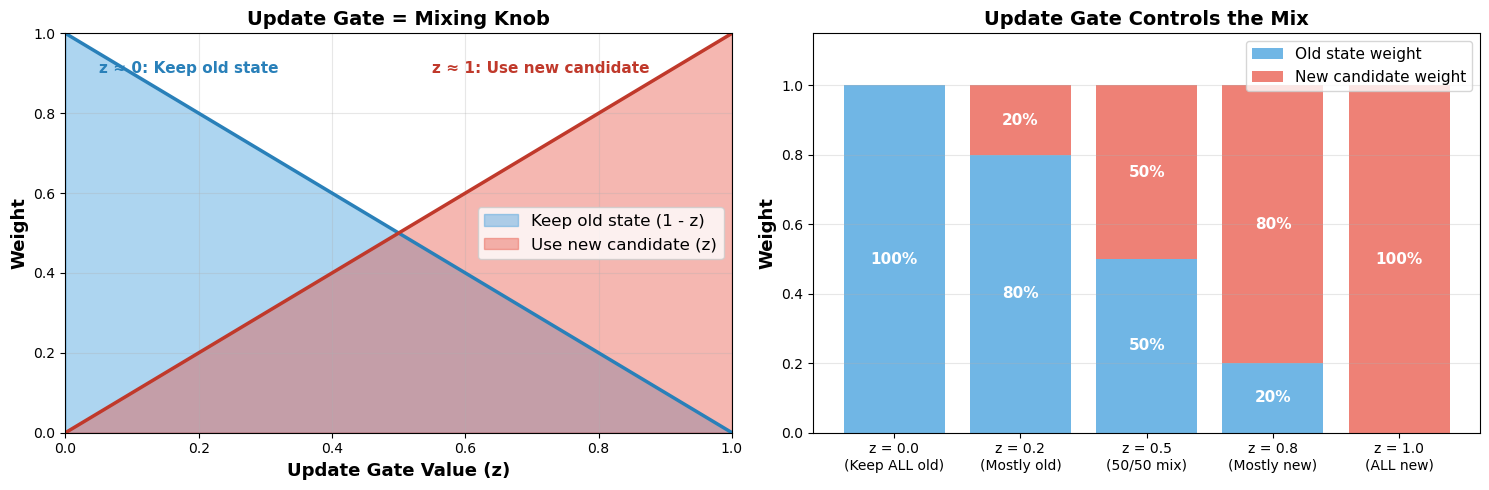

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/jupyter_client/session.py", line 100, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 560, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel/iostream.py", line 170, in _handle_event
    event_f()
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel/iostream.py", line 649, in _flush
    self.session.send(
  File "/opt/anaconda3/lib/python3.11/site-packages/jupyter_client/session.py", line 8

In [4]:
# Visualize how the update gate acts as a "mixing knob"

z_values = np.linspace(0, 1, 100)
keep_old = 1 - z_values   # (1 - z_t) * h_{t-1}
use_new = z_values         # z_t * h_candidate

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: The mixing knob
ax = axes[0]
ax.fill_between(z_values, 0, keep_old, alpha=0.4, color='#3498DB', label='Keep old state (1 - z)')
ax.fill_between(z_values, 0, use_new, alpha=0.4, color='#E74C3C', label='Use new candidate (z)')
ax.plot(z_values, keep_old, color='#2980B9', linewidth=2.5)
ax.plot(z_values, use_new, color='#C0392B', linewidth=2.5)
ax.set_xlabel('Update Gate Value (z)', fontsize=13, fontweight='bold')
ax.set_ylabel('Weight', fontsize=13, fontweight='bold')
ax.set_title('Update Gate = Mixing Knob', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='center right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Add annotations
ax.annotate('z \u2248 0: Keep old state', xy=(0.05, 0.9), fontsize=11,
            color='#2980B9', fontweight='bold')
ax.annotate('z \u2248 1: Use new candidate', xy=(0.55, 0.9), fontsize=11,
            color='#C0392B', fontweight='bold')

# Plot 2: Example with actual values
ax = axes[1]
scenarios = [
    ('z = 0.0\n(Keep ALL old)', 0.0),
    ('z = 0.2\n(Mostly old)', 0.2),
    ('z = 0.5\n(50/50 mix)', 0.5),
    ('z = 0.8\n(Mostly new)', 0.8),
    ('z = 1.0\n(ALL new)', 1.0),
]

x_pos = range(len(scenarios))
old_vals = [1 - s[1] for s in scenarios]
new_vals = [s[1] for s in scenarios]

bars1 = ax.bar(x_pos, old_vals, color='#3498DB', alpha=0.7, label='Old state weight')
bars2 = ax.bar(x_pos, new_vals, bottom=old_vals, color='#E74C3C', alpha=0.7, label='New candidate weight')

ax.set_xticks(x_pos)
ax.set_xticklabels([s[0] for s in scenarios], fontsize=10)
ax.set_ylabel('Weight', fontsize=13, fontweight='bold')
ax.set_title('Update Gate Controls the Mix', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, (label, z) in enumerate(scenarios):
    if 1 - z > 0.1:
        ax.text(i, (1 - z) / 2, f'{(1-z)*100:.0f}%', ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')
    if z > 0.1:
        ax.text(i, (1 - z) + z / 2, f'{z*100:.0f}%', ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

print("\n💡 The update gate is COMPLEMENTARY:")
print("   (1 - z) + z = 1   always!")
print("   Whatever you DON'T keep from the old state, you fill with new info.")
print("   This is more efficient than LSTM's separate forget + input gates.")

---

## Part 3: GRU Cell From Scratch

Time to build a full GRU cell using only NumPy. We will follow the equations step by step, so you can see exactly what happens inside.

### Reminder: The Four Steps

1. **Update gate**: $z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)$
2. **Reset gate**: $r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)$
3. **Candidate**: $\tilde{h}_t = \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t] + b_h)$
4. **New hidden state**: $h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$

In [5]:
def sigmoid(x):
    """Sigmoid activation: squashes input to (0, 1)."""
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


class GRUCell:
    """
    A single GRU (Gated Recurrent Unit) cell.
    
    At each time step, it takes an input x_t and the previous hidden state h_{t-1},
    and produces the next hidden state h_t using two gates:
    
    1. Update gate z_t: how much to update the hidden state
    2. Reset gate r_t:  how much of the old state is relevant for the candidate
    
    Equations:
        z_t = sigmoid(W_z @ [h_{t-1}, x_t] + b_z)         # Update gate
        r_t = sigmoid(W_r @ [h_{t-1}, x_t] + b_r)         # Reset gate
        h_candidate = tanh(W_h @ [r_t * h_{t-1}, x_t] + b_h)  # Candidate
        h_t = (1 - z_t) * h_{t-1} + z_t * h_candidate     # New hidden state
    """
    
    def __init__(self, input_size, hidden_size):
        """
        Parameters:
        - input_size:  dimension of each input vector x_t
        - hidden_size: dimension of the hidden state h_t
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        concat_size = hidden_size + input_size  # [h_{t-1}, x_t]
        
        # Xavier initialization for stable training
        scale = np.sqrt(2.0 / (concat_size + hidden_size))
        
        # Update gate parameters
        self.W_z = np.random.randn(hidden_size, concat_size) * scale
        self.b_z = np.zeros((hidden_size, 1))
        
        # Reset gate parameters
        self.W_r = np.random.randn(hidden_size, concat_size) * scale
        self.b_r = np.zeros((hidden_size, 1))
        
        # Candidate hidden state parameters
        self.W_h = np.random.randn(hidden_size, concat_size) * scale
        self.b_h = np.zeros((hidden_size, 1))
    
    def forward_step(self, x_t, h_prev):
        """
        One time step of the GRU.
        
        Parameters:
        - x_t:    input at time t, shape (input_size, 1)
        - h_prev: hidden state from time t-1, shape (hidden_size, 1)
        
        Returns:
        - h_t: new hidden state, shape (hidden_size, 1)
        - gates: dict with gate values for visualization
        """
        # Concatenate h_prev and x_t
        concat = np.vstack([h_prev, x_t])  # shape: (hidden_size + input_size, 1)
        
        # Step 1: Update gate
        z_t = sigmoid(self.W_z @ concat + self.b_z)
        
        # Step 2: Reset gate
        r_t = sigmoid(self.W_r @ concat + self.b_r)
        
        # Step 3: Candidate hidden state
        # Reset gate selectively zeroes out parts of h_prev
        reset_h = r_t * h_prev  # element-wise: which parts of old state to keep
        concat_reset = np.vstack([reset_h, x_t])  # [r_t * h_{t-1}, x_t]
        h_candidate = np.tanh(self.W_h @ concat_reset + self.b_h)
        
        # Step 4: Final hidden state (the mixing step)
        h_t = (1 - z_t) * h_prev + z_t * h_candidate
        
        gates = {
            'z': z_t.flatten(),       # update gate
            'r': r_t.flatten(),       # reset gate
            'h_candidate': h_candidate.flatten(),
        }
        
        return h_t, gates
    
    def forward_sequence(self, X):
        """
        Run the GRU over an entire sequence.
        
        Parameters:
        - X: input sequence, shape (seq_len, input_size)
        
        Returns:
        - hidden_states: array of shape (seq_len, hidden_size)
        - all_gates: list of gate dicts at each step
        """
        seq_len = X.shape[0]
        h = np.zeros((self.hidden_size, 1))  # initial hidden state
        hidden_states = []
        all_gates = []
        
        for t in range(seq_len):
            x_t = X[t].reshape(-1, 1)  # column vector
            h, gates = self.forward_step(x_t, h)
            hidden_states.append(h.flatten())
            all_gates.append(gates)
        
        return np.array(hidden_states), all_gates


# Let's test it!
print("✅ GRU Cell class defined!\n")
print("Let's verify with a quick test...\n")

np.random.seed(42)
input_size = 4
hidden_size = 3

gru = GRUCell(input_size, hidden_size)

# Single step test
x_test = np.random.randn(input_size, 1)
h_test = np.zeros((hidden_size, 1))

h_new, gates = gru.forward_step(x_test, h_test)

print(f"Input shape:           {x_test.shape}")
print(f"Previous hidden shape: {h_test.shape}")
print(f"New hidden shape:      {h_new.shape}")
print(f"\nUpdate gate (z): {gates['z']}")
print(f"Reset gate (r):  {gates['r']}")
print(f"New hidden state: {h_new.flatten()}")
print(f"\n💡 All gate values are between 0 and 1 (sigmoid output). \u2705")
print(f"   Hidden state values are between -1 and 1 (tanh output). \u2705")

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/jupyter_client/session.py", line 100, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 354-355: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 560, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel/iostream.py", line 170, in _handle_event
    event_f()
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel/iostream.py", line 649, in _flush
    self.session.send(
  File "/opt/anaconda3/lib/python3.11/site-packages/jupyter_client/session.py", line

---

## Part 4: Step-by-Step Walkthrough

Let's process a short sequence and watch what the GRU does at **every single step**. We will use a simple example: a sequence of 6 values representing words in a sentence.

Pay special attention to:
- What happens when the **update gate is near 0** (keep old state -- the crossfader is slid left)
- What happens when the **update gate is near 1** (use new candidate -- the crossfader is slid right)

In [ ]:
# Create a simple sequence and trace through the GRU step by step

np.random.seed(7)
input_size = 2
hidden_size = 3

gru_trace = GRUCell(input_size, hidden_size)

# A simple sequence: 6 time steps, 2-dim input
# Imagine these are simplified features of words in a sentence
X_trace = np.array([
    [1.0, 0.0],   # Step 0: "The"
    [0.5, 0.8],   # Step 1: "weather"
    [0.0, 0.1],   # Step 2: "is"      (boring word - should have low update)
    [-0.8, 0.9],  # Step 3: "really"   (intensifier)
    [0.9, -0.5],  # Step 4: "nice"     (important sentiment word)
    [0.1, 0.0],   # Step 5: "today"    (mild importance)
])

labels = ["The", "weather", "is", "really", "nice", "today"]

print("🚶 STEP-BY-STEP GRU WALKTHROUGH")
print("=" * 70)
print(f"Sentence: {' '.join(labels)}")
print(f"Input dimension: {input_size}, Hidden dimension: {hidden_size}")
print("=" * 70)

h = np.zeros((hidden_size, 1))

all_z = []  # store update gate values
all_r = []  # store reset gate values
all_h = []  # store hidden states

for t in range(len(X_trace)):
    x_t = X_trace[t].reshape(-1, 1)
    h_old = h.copy()
    h, gates = gru_trace.forward_step(x_t, h)
    
    all_z.append(gates['z'])
    all_r.append(gates['r'])
    all_h.append(h.flatten())
    
    z_mean = np.mean(gates['z'])
    r_mean = np.mean(gates['r'])
    
    print(f"\n--- Step {t}: \"{labels[t]}\" ---")
    print(f"  Input x_t:         {X_trace[t]}")
    print(f"  Update gate z_t:   {gates['z']}  (mean: {z_mean:.3f})")
    print(f"  Reset gate r_t:    {gates['r']}  (mean: {r_mean:.3f})")
    print(f"  h_prev:            {h_old.flatten()}")
    print(f"  h_new:             {h.flatten()}")
    
    # Interpret the gates
    if z_mean < 0.4:
        print(f"  \u27a1\ufe0f  Update gate LOW ({z_mean:.3f}): Mostly KEEPING the old state")
    elif z_mean > 0.6:
        print(f"  \u27a1\ufe0f  Update gate HIGH ({z_mean:.3f}): Mostly using NEW candidate")
    else:
        print(f"  \u27a1\ufe0f  Update gate MODERATE ({z_mean:.3f}): Balanced mix of old and new")
    
    if r_mean < 0.4:
        print(f"  \u27a1\ufe0f  Reset gate LOW ({r_mean:.3f}): Ignoring most of previous state for candidate")
    elif r_mean > 0.6:
        print(f"  \u27a1\ufe0f  Reset gate HIGH ({r_mean:.3f}): Using full previous state for candidate")
    else:
        print(f"  \u27a1\ufe0f  Reset gate MODERATE ({r_mean:.3f}): Partially using previous state")

print("\n" + "=" * 70)
print("\n💡 KEY OBSERVATIONS:")
print("   \u2022 When z \u2248 0: h_new \u2248 h_prev (old state preserved)")
print("   \u2022 When z \u2248 1: h_new \u2248 h_candidate (state fully updated)")
print("   \u2022 When r \u2248 0: candidate ignores old state (fresh computation)")
print("   \u2022 When r \u2248 1: candidate fully incorporates old state")

In [ ]:
# Visualize the gate values over the sequence

all_z_arr = np.array(all_z)  # shape: (seq_len, hidden_size)
all_r_arr = np.array(all_r)
all_h_arr = np.array(all_h)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: Update gate
im1 = axes[0].imshow(all_z_arr.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
axes[0].set_yticks(range(hidden_size))
axes[0].set_ylabel('Hidden Unit', fontsize=12, fontweight='bold')
axes[0].set_title('Update Gate (z) \u2014 "How much to update?"', fontsize=14, fontweight='bold', color='#E67E22')
plt.colorbar(im1, ax=axes[0], shrink=0.8)
# Add mean text on each cell
for t in range(len(labels)):
    for h_i in range(hidden_size):
        axes[0].text(t, h_i, f'{all_z_arr[t, h_i]:.2f}', ha='center', va='center',
                     fontsize=9, fontweight='bold', color='black' if all_z_arr[t, h_i] < 0.7 else 'white')

# Plot 2: Reset gate
im2 = axes[1].imshow(all_r_arr.T, aspect='auto', cmap='PuBuGn', vmin=0, vmax=1)
axes[1].set_yticks(range(hidden_size))
axes[1].set_ylabel('Hidden Unit', fontsize=12, fontweight='bold')
axes[1].set_title('Reset Gate (r) \u2014 "How much history is relevant?"', fontsize=14, fontweight='bold', color='#27AE60')
plt.colorbar(im2, ax=axes[1], shrink=0.8)
for t in range(len(labels)):
    for h_i in range(hidden_size):
        axes[1].text(t, h_i, f'{all_r_arr[t, h_i]:.2f}', ha='center', va='center',
                     fontsize=9, fontweight='bold', color='black' if all_r_arr[t, h_i] < 0.7 else 'white')

# Plot 3: Hidden state
im3 = axes[2].imshow(all_h_arr.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[2].set_yticks(range(hidden_size))
axes[2].set_ylabel('Hidden Unit', fontsize=12, fontweight='bold')
axes[2].set_title('Hidden State (h) \u2014 The GRU\'s Memory', fontsize=14, fontweight='bold', color='#2980B9')
plt.colorbar(im3, ax=axes[2], shrink=0.8)
for t in range(len(labels)):
    for h_i in range(hidden_size):
        axes[2].text(t, h_i, f'{all_h_arr[t, h_i]:.2f}', ha='center', va='center',
                     fontsize=9, fontweight='bold', color='black' if abs(all_h_arr[t, h_i]) < 0.6 else 'white')

# Set x-axis labels
axes[2].set_xticks(range(len(labels)))
axes[2].set_xticklabels(labels, fontsize=12, fontweight='bold')
axes[2].set_xlabel('Sequence Position', fontsize=13, fontweight='bold')

plt.suptitle('GRU Gate Activations Over the Sequence', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📊 What to look for:")
print("   \u2022 Update gate (top): High values (red) = state is being updated heavily")
print("   \u2022 Reset gate (middle): Low values = ignoring previous state for candidate")
print("   \u2022 Hidden state (bottom): How the memory evolves over time")

---

## Part 5: GRU vs LSTM -- Side-by-Side Comparison

Now that you have built a GRU, let's put it next to an LSTM and compare everything: gates, equations, and parameters.

### Equation Comparison

| Step | LSTM | GRU |
|------|------|-----|
| **Gate 1** | Forget gate: $f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)$ | Update gate: $z_t = \sigma(W_z[h_{t-1}, x_t] + b_z)$ |
| **Gate 2** | Input gate: $i_t = \sigma(W_i[h_{t-1}, x_t] + b_i)$ | Reset gate: $r_t = \sigma(W_r[h_{t-1}, x_t] + b_r)$ |
| **Gate 3** | Output gate: $o_t = \sigma(W_o[h_{t-1}, x_t] + b_o)$ | *None* |
| **Candidate** | $\tilde{C}_t = \tanh(W_C[h_{t-1}, x_t] + b_C)$ | $\tilde{h}_t = \tanh(W_h[r_t \odot h_{t-1}, x_t] + b_h)$ |
| **State update** | $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$ | $h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$ |
| **Output** | $h_t = o_t \odot \tanh(C_t)$ | *(h_t is the output directly)* |

### Gate Mapping

Think of it like a control panel being redesigned:

- GRU's **update gate** $z_t$ does the job of BOTH LSTM's forget gate ($f_t$) and input gate ($i_t$). Whatever the update gate does not keep $(1-z_t)$ from the old state, it fills with new info $(z_t)$. Two knobs merged into one crossfader.
- GRU's **reset gate** $r_t$ has no direct LSTM equivalent. It controls how the candidate is computed -- similar in spirit to how LSTM's cell state flows through the forget gate, but applied differently.
- LSTM's **output gate** has no GRU equivalent at all. GRU directly outputs $h_t$ with no extra filtering.

In [ ]:
# Also build a simple LSTM cell for direct comparison

class LSTMCell:
    """
    A simple LSTM cell for comparison with GRU.
    
    Has 3 gates (forget, input, output) + cell state + hidden state.
    """
    
    def __init__(self, input_size, hidden_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        concat_size = hidden_size + input_size
        scale = np.sqrt(2.0 / (concat_size + hidden_size))
        
        # Forget gate
        self.W_f = np.random.randn(hidden_size, concat_size) * scale
        self.b_f = np.zeros((hidden_size, 1))
        
        # Input gate
        self.W_i = np.random.randn(hidden_size, concat_size) * scale
        self.b_i = np.zeros((hidden_size, 1))
        
        # Output gate
        self.W_o = np.random.randn(hidden_size, concat_size) * scale
        self.b_o = np.zeros((hidden_size, 1))
        
        # Cell candidate
        self.W_c = np.random.randn(hidden_size, concat_size) * scale
        self.b_c = np.zeros((hidden_size, 1))
    
    def forward_step(self, x_t, h_prev, c_prev):
        concat = np.vstack([h_prev, x_t])
        
        f_t = sigmoid(self.W_f @ concat + self.b_f)  # forget gate
        i_t = sigmoid(self.W_i @ concat + self.b_i)  # input gate
        o_t = sigmoid(self.W_o @ concat + self.b_o)  # output gate
        c_candidate = np.tanh(self.W_c @ concat + self.b_c)
        
        c_t = f_t * c_prev + i_t * c_candidate
        h_t = o_t * np.tanh(c_t)
        
        gates = {
            'f': f_t.flatten(), 'i': i_t.flatten(),
            'o': o_t.flatten(), 'c_candidate': c_candidate.flatten()
        }
        return h_t, c_t, gates
    
    def forward_sequence(self, X):
        seq_len = X.shape[0]
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))
        hidden_states = []
        all_gates = []
        
        for t in range(seq_len):
            x_t = X[t].reshape(-1, 1)
            h, c, gates = self.forward_step(x_t, h, c)
            hidden_states.append(h.flatten())
            all_gates.append(gates)
        
        return np.array(hidden_states), all_gates


print("✅ LSTM Cell class defined for comparison!\n")

# Run both on the same input
np.random.seed(42)
input_size = 4
hidden_size = 6
seq_len = 10

X_compare = np.random.randn(seq_len, input_size)

# Create cells
gru_cell = GRUCell(input_size, hidden_size)
lstm_cell = LSTMCell(input_size, hidden_size)

# Run both
gru_states, gru_gates = gru_cell.forward_sequence(X_compare)
lstm_states, lstm_gates = lstm_cell.forward_sequence(X_compare)

print(f"Sequence length: {seq_len}")
print(f"Input size: {input_size}")
print(f"Hidden size: {hidden_size}")
print(f"\nGRU hidden states shape:  {gru_states.shape}")
print(f"LSTM hidden states shape: {lstm_states.shape}")
print(f"\n\u2022 Both produce hidden states of the same shape!")
print(f"\u2022 But GRU has fewer parameters (no output gate, no cell state computation)")

In [ ]:
# Visualize GRU gates vs LSTM gates side by side

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

time_steps = range(seq_len)

# --- Top row: LSTM gates ---
# LSTM forget gate
lstm_f_vals = np.array([g['f'] for g in lstm_gates])
im = axes[0, 0].imshow(lstm_f_vals.T, aspect='auto', cmap='Reds', vmin=0, vmax=1)
axes[0, 0].set_title('LSTM: Forget Gate', fontsize=13, fontweight='bold', color='#E74C3C')
axes[0, 0].set_ylabel('Hidden Unit', fontsize=11)
plt.colorbar(im, ax=axes[0, 0], shrink=0.8)

# LSTM input gate
lstm_i_vals = np.array([g['i'] for g in lstm_gates])
im = axes[0, 1].imshow(lstm_i_vals.T, aspect='auto', cmap='Greens', vmin=0, vmax=1)
axes[0, 1].set_title('LSTM: Input Gate', fontsize=13, fontweight='bold', color='#27AE60')
plt.colorbar(im, ax=axes[0, 1], shrink=0.8)

# LSTM output gate
lstm_o_vals = np.array([g['o'] for g in lstm_gates])
im = axes[0, 2].imshow(lstm_o_vals.T, aspect='auto', cmap='Blues', vmin=0, vmax=1)
axes[0, 2].set_title('LSTM: Output Gate', fontsize=13, fontweight='bold', color='#2980B9')
plt.colorbar(im, ax=axes[0, 2], shrink=0.8)

# --- Bottom row: GRU gates ---
# GRU update gate (spans 2 columns to emphasize it replaces forget+input)
gru_z_vals = np.array([g['z'] for g in gru_gates])
im = axes[1, 0].imshow(gru_z_vals.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
axes[1, 0].set_title('GRU: Update Gate (z)\n\u2248 Forget + Input combined', fontsize=13,
                       fontweight='bold', color='#E67E22')
axes[1, 0].set_ylabel('Hidden Unit', fontsize=11)
axes[1, 0].set_xlabel('Time Step', fontsize=11)
plt.colorbar(im, ax=axes[1, 0], shrink=0.8)

# GRU reset gate
gru_r_vals = np.array([g['r'] for g in gru_gates])
im = axes[1, 1].imshow(gru_r_vals.T, aspect='auto', cmap='PuBuGn', vmin=0, vmax=1)
axes[1, 1].set_title('GRU: Reset Gate (r)\nControls candidate computation', fontsize=13,
                       fontweight='bold', color='#27AE60')
axes[1, 1].set_xlabel('Time Step', fontsize=11)
plt.colorbar(im, ax=axes[1, 1], shrink=0.8)

# No output gate for GRU
axes[1, 2].text(0.5, 0.5, 'No Output Gate!\n\nGRU directly uses\nh_t as the output.\n\nThis is one reason\nGRU has fewer parameters.',
                ha='center', va='center', fontsize=13, fontweight='bold',
                transform=axes[1, 2].transAxes, color='gray',
                bbox=dict(boxstyle='round', facecolor='#F2F3F4', edgecolor='gray', linewidth=2))
axes[1, 2].set_title('GRU: (No Output Gate)', fontsize=13, fontweight='bold', color='gray')
axes[1, 2].axis('off')

# Add row labels
fig.text(0.01, 0.73, 'LSTM\n(3 gates)', fontsize=14, fontweight='bold', color='#8E44AD',
         ha='center', va='center')
fig.text(0.01, 0.27, 'GRU\n(2 gates)', fontsize=14, fontweight='bold', color='#E67E22',
         ha='center', va='center')

plt.suptitle('LSTM Gates vs GRU Gates', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 KEY DIFFERENCE:")
print("   LSTM has 3 independent gates \u2192 more flexible but more parameters")
print("   GRU has 2 gates (update combines forget+input) \u2192 simpler and faster")
print("   GRU has NO output gate \u2014 the hidden state IS the output")

---

## Part 6: Visualizing Gate Activations on a Longer Sequence

Let's feed a longer sequence through the GRU and watch how the gates behave over time. We will create a signal with different phases -- a smooth wave, a sudden spike, and some noise -- and see how the gates respond to each one.

In [ ]:
# Create a more interesting sequence with different regimes

np.random.seed(42)

# A sequence with 3 phases:
# Phase 1: steady signal (should learn to keep state)
# Phase 2: sudden change (should learn to update state)
# Phase 3: noisy signal (interesting gate behavior)

t_points = np.linspace(0, 4 * np.pi, 40)

# 2D input signal
signal_1 = np.sin(t_points)                # smooth sine wave
signal_2 = np.zeros_like(t_points)
signal_2[15:25] = 1.5                       # sudden spike in the middle
signal_2 += np.random.randn(40) * 0.1       # small noise

X_long = np.column_stack([signal_1, signal_2])  # shape: (40, 2)

# Run through a GRU
hidden_size_long = 8
gru_long = GRUCell(2, hidden_size_long)
states_long, gates_long = gru_long.forward_sequence(X_long)

# Extract gate values
z_vals_long = np.array([g['z'] for g in gates_long])  # (40, 8)
r_vals_long = np.array([g['r'] for g in gates_long])  # (40, 8)

# Plot everything
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# Plot 1: Input signal
axes[0].plot(signal_1, 'b-', linewidth=2, label='Signal 1 (sine wave)', alpha=0.8)
axes[0].plot(signal_2, 'r-', linewidth=2, label='Signal 2 (spike + noise)', alpha=0.8)
axes[0].axvspan(15, 25, alpha=0.15, color='red', label='Spike region')
axes[0].set_ylabel('Input Value', fontsize=12, fontweight='bold')
axes[0].set_title('Input Signals', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 2: Update gate
im2 = axes[1].imshow(z_vals_long.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
axes[1].set_ylabel('Hidden Unit', fontsize=12, fontweight='bold')
axes[1].set_title('Update Gate (z) \u2014 "How much to update at each step?"', fontsize=14, fontweight='bold', color='#E67E22')
plt.colorbar(im2, ax=axes[1], shrink=0.8)
axes[1].axvline(x=15, color='white', linestyle='--', linewidth=1.5)
axes[1].axvline(x=25, color='white', linestyle='--', linewidth=1.5)

# Plot 3: Reset gate
im3 = axes[2].imshow(r_vals_long.T, aspect='auto', cmap='PuBuGn', vmin=0, vmax=1)
axes[2].set_ylabel('Hidden Unit', fontsize=12, fontweight='bold')
axes[2].set_title('Reset Gate (r) \u2014 "How much history matters?"', fontsize=14, fontweight='bold', color='#27AE60')
plt.colorbar(im3, ax=axes[2], shrink=0.8)
axes[2].axvline(x=15, color='white', linestyle='--', linewidth=1.5)
axes[2].axvline(x=25, color='white', linestyle='--', linewidth=1.5)

# Plot 4: Mean gate values over time
z_mean = z_vals_long.mean(axis=1)
r_mean = r_vals_long.mean(axis=1)
axes[3].plot(z_mean, 'o-', color='#E67E22', linewidth=2, markersize=4, label='Mean Update Gate (z)', alpha=0.8)
axes[3].plot(r_mean, 's-', color='#27AE60', linewidth=2, markersize=4, label='Mean Reset Gate (r)', alpha=0.8)
axes[3].axvspan(15, 25, alpha=0.15, color='red')
axes[3].set_ylabel('Mean Gate Value', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Time Step', fontsize=12, fontweight='bold')
axes[3].set_title('Mean Gate Values Over Time', fontsize=14, fontweight='bold')
axes[3].legend(fontsize=11)
axes[3].grid(True, alpha=0.3)
axes[3].set_ylim(-0.05, 1.05)

plt.suptitle('GRU Gate Activations on a Multi-Phase Signal', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📊 What to observe:")
print("   \u2022 Dashed white lines mark the spike region (steps 15-25)")
print("   \u2022 Watch how gates react to the sudden change in signal")
print("   \u2022 Each hidden unit can learn different gate patterns!")
print("   \u2022 The bottom plot shows average gate values for easy comparison")

---

## Part 7: Practical Example -- Sequence Prediction

Let's train a GRU on a real task: predicting the next value in a sine wave. We will also train a vanilla RNN on the same data so you can compare them head-to-head.

The training loop uses:
- Forward pass through the GRU
- Mean Squared Error loss
- Numerical gradient computation (slow but simple -- no manual backpropagation through time)

In [ ]:
class SimpleGRUPredictor:
    """
    A simple GRU-based sequence predictor.
    
    Architecture:
        Input -> GRU -> Linear -> Output
    
    Uses numerical gradients for simplicity (not efficient, but clear).
    """
    
    def __init__(self, input_size, hidden_size, output_size):
        self.hidden_size = hidden_size
        
        # GRU cell
        self.gru = GRUCell(input_size, hidden_size)
        
        # Output layer: hidden_size -> output_size
        scale_out = np.sqrt(2.0 / (hidden_size + output_size))
        self.W_out = np.random.randn(output_size, hidden_size) * scale_out
        self.b_out = np.zeros((output_size, 1))
    
    def predict(self, X):
        """Run GRU on sequence X and produce a prediction from the final hidden state."""
        hidden_states, _ = self.gru.forward_sequence(X)
        h_final = hidden_states[-1].reshape(-1, 1)  # last hidden state
        output = self.W_out @ h_final + self.b_out
        return output.flatten(), hidden_states
    
    def get_all_params(self):
        """Collect all parameters into a flat list for numerical gradient computation."""
        return [
            self.gru.W_z, self.gru.b_z,
            self.gru.W_r, self.gru.b_r,
            self.gru.W_h, self.gru.b_h,
            self.W_out, self.b_out
        ]


class SimpleRNNPredictor:
    """
    A vanilla RNN predictor for comparison.
    
    Architecture:
        Input -> Vanilla RNN -> Linear -> Output
    """
    
    def __init__(self, input_size, hidden_size, output_size):
        self.hidden_size = hidden_size
        
        concat_size = hidden_size + input_size
        scale = np.sqrt(2.0 / (concat_size + hidden_size))
        
        # RNN parameters
        self.W_h = np.random.randn(hidden_size, concat_size) * scale
        self.b_h = np.zeros((hidden_size, 1))
        
        # Output layer
        scale_out = np.sqrt(2.0 / (hidden_size + output_size))
        self.W_out = np.random.randn(output_size, hidden_size) * scale_out
        self.b_out = np.zeros((output_size, 1))
    
    def predict(self, X):
        seq_len = X.shape[0]
        h = np.zeros((self.hidden_size, 1))
        hidden_states = []
        for t in range(seq_len):
            x_t = X[t].reshape(-1, 1)
            concat = np.vstack([h, x_t])
            h = np.tanh(self.W_h @ concat + self.b_h)
            hidden_states.append(h.flatten())
        
        output = self.W_out @ h + self.b_out
        return output.flatten(), np.array(hidden_states)
    
    def get_all_params(self):
        return [self.W_h, self.b_h, self.W_out, self.b_out]


def compute_loss(prediction, target):
    """Mean Squared Error."""
    return np.mean((prediction - target) ** 2)


def numerical_gradient(model, X, target, epsilon=1e-5):
    """
    Compute gradients numerically for all parameters.
    This is slow but correct and easy to understand.
    """
    params = model.get_all_params()
    grads = []
    
    for param in params:
        grad = np.zeros_like(param)
        it = np.nditer(param, flags=['multi_index'])
        while not it.finished:
            idx = it.multi_index
            old_val = param[idx]
            
            param[idx] = old_val + epsilon
            pred_plus, _ = model.predict(X)
            loss_plus = compute_loss(pred_plus, target)
            
            param[idx] = old_val - epsilon
            pred_minus, _ = model.predict(X)
            loss_minus = compute_loss(pred_minus, target)
            
            grad[idx] = (loss_plus - loss_minus) / (2 * epsilon)
            param[idx] = old_val
            it.iternext()
        
        grads.append(grad)
    
    return grads


print("✅ Predictor classes and training utilities defined!")
print("\n📝 Architecture:")
print("   Input sequence \u2192 GRU (or Vanilla RNN) \u2192 Linear layer \u2192 Prediction")
print("\n   We use numerical gradients for clarity (slower but simple).")

In [ ]:
# Generate training data: predict the next value of a sine wave

np.random.seed(42)

# Generate sine wave data
t = np.linspace(0, 8 * np.pi, 200)
data = np.sin(t)

# Create input/output pairs: use window of 5 to predict the 6th value
window_size = 5
X_data = []
y_data = []

for i in range(len(data) - window_size):
    X_data.append(data[i:i + window_size].reshape(-1, 1))  # (5, 1)
    y_data.append(data[i + window_size])

X_data = np.array(X_data)  # (195, 5, 1)
y_data = np.array(y_data)  # (195,)

print(f"📈 Dataset:")
print(f"   Total samples: {len(X_data)}")
print(f"   Input shape per sample: {X_data[0].shape} (window_size={window_size}, features=1)")
print(f"   Target: single value (next point in the sine wave)")

# Train both models
hidden_size_train = 6
lr = 0.01
n_epochs = 50
n_samples_per_epoch = 30  # use a subset for speed (numerical gradients are slow!)

# Initialize models
np.random.seed(42)
gru_model = SimpleGRUPredictor(1, hidden_size_train, 1)
np.random.seed(42)
rnn_model = SimpleRNNPredictor(1, hidden_size_train, 1)

gru_losses = []
rnn_losses = []

print(f"\n🏋\ufe0f Training for {n_epochs} epochs (using {n_samples_per_epoch} samples per epoch)...")
print(f"   Hidden size: {hidden_size_train}, Learning rate: {lr}")
print()

for epoch in range(n_epochs):
    # Random subset of training data
    indices = np.random.choice(len(X_data), n_samples_per_epoch, replace=False)
    
    epoch_gru_loss = 0
    epoch_rnn_loss = 0
    
    for idx in indices:
        X_sample = X_data[idx]
        y_target = y_data[idx:idx+1]
        
        # --- GRU ---
        gru_pred, _ = gru_model.predict(X_sample)
        gru_loss = compute_loss(gru_pred, y_target)
        epoch_gru_loss += gru_loss
        
        gru_grads = numerical_gradient(gru_model, X_sample, y_target)
        gru_params = gru_model.get_all_params()
        for param, grad in zip(gru_params, gru_grads):
            param -= lr * np.clip(grad, -1.0, 1.0)  # gradient clipping
        
        # --- Vanilla RNN ---
        rnn_pred, _ = rnn_model.predict(X_sample)
        rnn_loss = compute_loss(rnn_pred, y_target)
        epoch_rnn_loss += rnn_loss
        
        rnn_grads = numerical_gradient(rnn_model, X_sample, y_target)
        rnn_params = rnn_model.get_all_params()
        for param, grad in zip(rnn_params, rnn_grads):
            param -= lr * np.clip(grad, -1.0, 1.0)
    
    gru_losses.append(epoch_gru_loss / n_samples_per_epoch)
    rnn_losses.append(epoch_rnn_loss / n_samples_per_epoch)
    
    if (epoch + 1) % 10 == 0:
        print(f"   Epoch {epoch+1:3d}/{n_epochs} | GRU Loss: {gru_losses[-1]:.4f} | RNN Loss: {rnn_losses[-1]:.4f}")

print("\n\u2705 Training complete!")

In [ ]:
# Plot training curves and predictions

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Training loss
axes[0].plot(gru_losses, 'o-', color='#E67E22', linewidth=2, markersize=3, label='GRU', alpha=0.8)
axes[0].plot(rnn_losses, 's-', color='#2980B9', linewidth=2, markersize=3, label='Vanilla RNN', alpha=0.8)
axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mean Squared Error', fontsize=13, fontweight='bold')
axes[0].set_title('Training Loss: GRU vs Vanilla RNN', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Predictions on a test range
test_range = range(50, 100)
gru_preds = []
rnn_preds = []
actuals = []

for idx in test_range:
    gru_pred, _ = gru_model.predict(X_data[idx])
    rnn_pred, _ = rnn_model.predict(X_data[idx])
    gru_preds.append(gru_pred[0])
    rnn_preds.append(rnn_pred[0])
    actuals.append(y_data[idx])

axes[1].plot(actuals, 'k-', linewidth=2.5, label='Actual', alpha=0.8)
axes[1].plot(gru_preds, 'o--', color='#E67E22', linewidth=1.5, markersize=4, label='GRU Prediction', alpha=0.8)
axes[1].plot(rnn_preds, 's--', color='#2980B9', linewidth=1.5, markersize=4, label='RNN Prediction', alpha=0.8)
axes[1].set_xlabel('Test Sample Index', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Value', fontsize=13, fontweight='bold')
axes[1].set_title('Predictions on Test Data', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute final test metrics
gru_test_loss = np.mean((np.array(gru_preds) - np.array(actuals)) ** 2)
rnn_test_loss = np.mean((np.array(rnn_preds) - np.array(actuals)) ** 2)

print(f"\n📊 Test Results:")
print(f"   GRU Test MSE:         {gru_test_loss:.6f}")
print(f"   Vanilla RNN Test MSE: {rnn_test_loss:.6f}")
if gru_test_loss < rnn_test_loss:
    print(f"   \u2192 GRU is {rnn_test_loss/gru_test_loss:.1f}x better!")
else:
    print(f"   \u2192 RNN is {gru_test_loss/rnn_test_loss:.1f}x better (uncommon for longer sequences)")

print("\n💡 Note: With numerical gradients and small training, results may vary.")
print("   In practice with proper backpropagation, GRU consistently outperforms")
print("   vanilla RNNs on tasks requiring longer-term memory.")

---

## Part 8: Parameter Count Comparison

One of GRU's biggest selling points is having **fewer parameters** than LSTM. Let's do the exact math so you can see why.

### The Formulas

For a single layer with `input_size = n` and `hidden_size = h`:

**Vanilla RNN:**
- One weight matrix $W$: maps $[h_{t-1}, x_t]$ to $h_t$, so shape is $(h, h+n)$
- One bias: shape $(h,)$
- **Total: $h \times (h + n) + h = h(h + n + 1)$**

**GRU (2 gates + candidate = 3 weight matrices):**
- Update gate $W_z$: $(h, h+n)$ + bias $(h,)$
- Reset gate $W_r$: $(h, h+n)$ + bias $(h,)$
- Candidate $W_h$: $(h, h+n)$ + bias $(h,)$
- **Total: $3 \times [h(h + n) + h] = 3h(h + n + 1)$**

**LSTM (3 gates + candidate = 4 weight matrices):**
- Forget gate $W_f$: $(h, h+n)$ + bias $(h,)$
- Input gate $W_i$: $(h, h+n)$ + bias $(h,)$
- Output gate $W_o$: $(h, h+n)$ + bias $(h,)$
- Cell candidate $W_c$: $(h, h+n)$ + bias $(h,)$
- **Total: $4 \times [h(h + n) + h] = 4h(h + n + 1)$**

The ratio is simple: GRU has 3 weight matrices, LSTM has 4. So GRU always has exactly **3/4 = 75%** of LSTM's parameters. That means 25% fewer weights to store, update, and train.

In [ ]:
# Calculate exact parameter counts

def count_params(model_type, input_size, hidden_size):
    """
    Count the number of learnable parameters.
    
    model_type: 'rnn', 'gru', or 'lstm'
    """
    h = hidden_size
    n = input_size
    params_per_gate = h * (h + n) + h  # weight matrix + bias
    
    if model_type == 'rnn':
        return 1 * params_per_gate  # 1 transformation
    elif model_type == 'gru':
        return 3 * params_per_gate  # update gate + reset gate + candidate
    elif model_type == 'lstm':
        return 4 * params_per_gate  # forget + input + output + candidate


# Example 1: Typical NLP setup
h, n = 128, 64

rnn_params = count_params('rnn', n, h)
gru_params = count_params('gru', n, h)
lstm_params = count_params('lstm', n, h)

print("💰 PARAMETER COUNT COMPARISON")
print("=" * 70)
print(f"\nSettings: hidden_size = {h}, input_size = {n}")
print(f"\n{'Model':<15} {'Parameters':>12} {'Relative to RNN':>18} {'Relative to LSTM':>18}")
print("-" * 65)
print(f"{'Vanilla RNN':<15} {rnn_params:>12,} {'1.0x':>18} {rnn_params/lstm_params:>17.2f}x")
print(f"{'GRU':<15} {gru_params:>12,} {gru_params/rnn_params:>17.1f}x {gru_params/lstm_params:>17.2f}x")
print(f"{'LSTM':<15} {lstm_params:>12,} {lstm_params/rnn_params:>17.1f}x {'1.0x':>18}")

print(f"\n💡 GRU has {(1 - gru_params/lstm_params)*100:.0f}% fewer parameters than LSTM!")
print(f"   GRU savings: {lstm_params - gru_params:,} parameters")

# Example 2: Larger setup
print("\n" + "=" * 70)
print("\n📈 Scaling comparison with different sizes:\n")

configs = [(32, 16), (64, 32), (128, 64), (256, 128), (512, 256)]

print(f"{'hidden':>8} {'input':>8} {'Vanilla RNN':>14} {'GRU':>14} {'LSTM':>14} {'GRU Savings':>14}")
print("-" * 75)
for h, n in configs:
    r = count_params('rnn', n, h)
    g = count_params('gru', n, h)
    l = count_params('lstm', n, h)
    print(f"{h:>8} {n:>8} {r:>14,} {g:>14,} {l:>14,} {l-g:>13,} ({(1-g/l)*100:.0f}%)")

print("\n💡 As models get larger, the absolute savings from using GRU grow significantly!")

In [ ]:
# Visualize parameter counts

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Bar chart for hidden_size=128, input_size=64
ax = axes[0]
models = ['Vanilla RNN', 'GRU', 'LSTM']
counts = [rnn_params, gru_params, lstm_params]
colors = ['#3498DB', '#E67E22', '#8E44AD']

bars = ax.bar(models, counts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_ylabel('Number of Parameters', fontsize=13, fontweight='bold')
ax.set_title(f'Parameter Count (h={128}, n={64})', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add ratio labels
ax.text(1, gru_params / 2, f'{gru_params/lstm_params:.0%}\nof LSTM', ha='center',
        va='center', fontsize=11, fontweight='bold', color='white')

# Plot 2: Scaling with hidden size
ax = axes[1]
hidden_sizes = [16, 32, 64, 128, 256, 512]
input_size_plot = 64

rnn_counts = [count_params('rnn', input_size_plot, h) for h in hidden_sizes]
gru_counts = [count_params('gru', input_size_plot, h) for h in hidden_sizes]
lstm_counts = [count_params('lstm', input_size_plot, h) for h in hidden_sizes]

ax.plot(hidden_sizes, rnn_counts, 'o-', color='#3498DB', linewidth=2.5, markersize=8, label='Vanilla RNN')
ax.plot(hidden_sizes, gru_counts, 's-', color='#E67E22', linewidth=2.5, markersize=8, label='GRU')
ax.plot(hidden_sizes, lstm_counts, '^-', color='#8E44AD', linewidth=2.5, markersize=8, label='LSTM')

ax.set_xlabel('Hidden Size', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Parameters', fontsize=13, fontweight='bold')
ax.set_title(f'Parameter Scaling (input_size={input_size_plot})', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Annotate the gap
ax.annotate('~25% fewer\nparams', xy=(256, gru_counts[4]),
            xytext=(350, gru_counts[4] * 0.3),
            fontsize=11, fontweight='bold', color='#E67E22',
            arrowprops=dict(arrowstyle='->', lw=2, color='#E67E22'))

plt.tight_layout()
plt.show()

print("\n💡 Key Takeaway:")
print(f"   GRU always has exactly 75% of LSTM's parameters (3/4 ratio)")
print(f"   Because GRU has 3 weight matrices vs LSTM's 4")
print(f"   This means ~25% less memory and ~25% faster training!")

In [ ]:
# THE CROSSFADER EXPERIMENT: Visualize update gate behavior

print("THE CROSSFADER EXPERIMENT")
print("=" * 60)
print("We'll manually control the update gate and watch what happens")
print("to the hidden state as it blends old memory with new input.")
print("=" * 60)

np.random.seed(42)
hidden_size_xfade = 6
input_size_xfade = 4
seq_len_xfade = 20

# Create a sequence with two distinct phases:
# Phase 1 (steps 0-9): Type A inputs
# Phase 2 (steps 10-19): Type B inputs (very different)
np.random.seed(42)
phase_A = np.random.randn(10, input_size_xfade) + np.array([2, 0, -2, 0])  # centered around [2,0,-2,0]
phase_B = np.random.randn(10, input_size_xfade) + np.array([-2, 0, 2, 0])  # centered around [-2,0,2,0]
X_xfade = np.vstack([phase_A, phase_B])

# Run GRU with different fixed update gate values
z_values_to_test = [0.0, 0.3, 0.5, 0.7, 1.0]

fig, axes = plt.subplots(len(z_values_to_test), 1, figsize=(14, 12), sharex=True)

for ax_idx, fixed_z in enumerate(z_values_to_test):
    # Manually run a GRU with this fixed z value
    h = np.zeros((hidden_size_xfade, 1))
    states_fixed = []
    
    # Use random but fixed GRU weights
    np.random.seed(99)
    gru_fixed = GRUCell(input_size_xfade, hidden_size_xfade)
    
    for t in range(seq_len_xfade):
        x_t = X_xfade[t].reshape(-1, 1)
        concat = np.vstack([h, x_t])
        # Use real reset gate, but FORCE update gate to fixed_z
        r_t = sigmoid(gru_fixed.W_r @ concat + gru_fixed.b_r)
        concat_reset = np.vstack([r_t * h, x_t])
        h_candidate = np.tanh(gru_fixed.W_h @ concat_reset + gru_fixed.b_h)
        # Override: force update gate to fixed_z
        z_forced = np.full((hidden_size_xfade, 1), fixed_z)
        h = (1 - z_forced) * h + z_forced * h_candidate
        states_fixed.append(h.flatten().copy())
    
    states_arr = np.array(states_fixed)
    
    im = axes[ax_idx].imshow(states_arr.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    axes[ax_idx].axvline(x=9.5, color='yellow', linestyle='--', linewidth=2.5, alpha=0.9)
    axes[ax_idx].set_ylabel(f'z={fixed_z:.1f}\nhidden unit', fontsize=9, fontweight='bold')
    
    if fixed_z == 0.0:
        axes[ax_idx].set_title(f'Update gate z = {fixed_z:.1f}  ->  FROZEN (ignores new input, preserves old memory)',
                               fontsize=11, fontweight='bold', color='#2980B9')
    elif fixed_z == 1.0:
        axes[ax_idx].set_title(f'Update gate z = {fixed_z:.1f}  ->  FULLY UPDATING (ignores old memory, pure new input)',
                               fontsize=11, fontweight='bold', color='#E74C3C')
    else:
        axes[ax_idx].set_title(f'Update gate z = {fixed_z:.1f}  ->  BLENDED (mix of old and new)',
                               fontsize=11, fontweight='bold', color='#27AE60')

axes[-1].set_xlabel('Time Step  (yellow dashed line = phase change)', fontsize=12, fontweight='bold')
plt.suptitle('How the Update Gate Controls Memory Plasticity\n(Notice how Phase B inputs change the hidden state differently for each z value)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  z = 0.0: The hidden state barely changes at all -- it's locked in place.")
print("           Even the phase change at step 10 makes almost no difference!")
print("  z = 0.5: Gradual blend. Notice how the phase change slowly seeps in.")
print("  z = 1.0: Immediate update! The phase change at step 10 is instant.")
print("           But it also forgets everything from Phase A immediately.")
print()
print("A trained GRU learns to set z close to 0 for important info it wants")
print("to preserve, and z close to 1 when new information is important.")

---

## Bonus: The Crossfader in Action -- Exploring Update Gate Behavior

The update gate is like a DJ's crossfader. Let's **manually set** the update gate to different values and watch exactly how the hidden state blends old and new information.

This is the kind of experiment that makes an abstract formula feel concrete. You'll see that:
- `z = 0.0` -- the hidden state is frozen (pure memory, ignores new input)
- `z = 1.0` -- the hidden state completely updates (pure plasticity, ignores past)
- `z = 0.5` -- equal blend of old and new

In a trained GRU, the network **learns** to set z to 0 when it wants to remember something across many steps, and z to 1 when new important information arrives.

---

## Part 9: Summary

### GRU Cheat Sheet

| Property | Details |
|----------|---------|  
| **Full Name** | Gated Recurrent Unit |
| **Introduced** | Cho et al., 2014 |
| **Number of Gates** | 2 (Update gate $z_t$, Reset gate $r_t$) |
| **State Vectors** | 1 (hidden state $h_t$ only -- no separate cell state) |
| **Key Equations** | $z_t = \sigma(W_z[h_{t-1}, x_t])$, $r_t = \sigma(W_r[h_{t-1}, x_t])$, $\tilde{h}_t = \tanh(W_h[r_t \odot h_{t-1}, x_t])$, $h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$ |
| **Parameters** | $3h(h + n + 1)$ -- 75% of LSTM |
| **Strengths** | Fewer parameters, faster training, simpler implementation, comparable performance |
| **Weaknesses** | Slightly less expressive than LSTM on some complex tasks |

### When to Choose GRU vs LSTM

| Choose GRU When... | Choose LSTM When... |
|---------------------|---------------------|
| You have limited computational resources | You have plenty of compute and data |
| You need faster training or inference | Maximum accuracy matters more than speed |
| Your dataset is relatively small | Your dataset is very large |
| You are prototyping and need quick iteration | You are building a production system with proven LSTM baselines |
| The task does not require very long-range dependencies | The task requires very long-range dependencies |
| You are not sure -- try GRU first | GRU did not work well enough and you want more capacity |

### Key Takeaways

1. **GRU simplifies LSTM** by merging the forget and input gates into a single **update gate** (the crossfader) and dropping the output gate entirely.

2. **No separate cell state.** GRU uses only the hidden state. This makes the architecture simpler and the information flow more direct.

3. **The update gate is complementary.** $(1 - z_t) + z_t = 1$ always. This prevents information from being simultaneously forgotten AND not replaced.

4. **25% fewer parameters.** GRU has 3 weight matrices (update, reset, candidate) vs LSTM's 4 (forget, input, output, candidate). Fewer parameters means less memory and faster training.

5. **In practice, GRU and LSTM perform similarly** on many tasks. GRU is often the better starting point because it trains faster.

6. **Rule of thumb:** Start with GRU. If it is not good enough, try LSTM. If LSTM is not good enough, try Transformers.

---

## Test Your Understanding

1. **What are the two gates in a GRU, and what does each one control?**
   <details>
   <summary>Click to reveal answer</summary>
   The Update Gate (z) controls how much of the old hidden state to keep vs. how much new information to add -- like a crossfader between old and new. The Reset Gate (r) controls how much of the previous hidden state is relevant for computing the new candidate -- like a fresh-start button.
   </details>

2. **Why does GRU have fewer parameters than LSTM?**
   <details>
   <summary>Click to reveal answer</summary>
   GRU has 3 weight matrices (update gate, reset gate, candidate) while LSTM has 4 (forget gate, input gate, output gate, candidate). That means GRU has 3/4 = 75% of LSTM's parameters. GRU also has no separate cell state computation.
   </details>

3. **What happens when the update gate z_t is close to 0? What about close to 1?**
   <details>
   <summary>Click to reveal answer</summary>
   When z_t is close to 0: h_t = (1-0) * h_{t-1} + 0 * h_candidate = h_{t-1}. The old hidden state is kept almost entirely (the new candidate is ignored). When z_t is close to 1: h_t = (1-1) * h_{t-1} + 1 * h_candidate = h_candidate. The old state is replaced entirely by the new candidate.
   </details>

4. **How does GRU's update gate combine the roles of LSTM's forget and input gates?**
   <details>
   <summary>Click to reveal answer</summary>
   In LSTM, the forget gate and input gate are independent: f_t and i_t can each be any value between 0 and 1. In GRU, the update gate z_t replaces both: the "forget" portion is (1 - z_t) and the "input" portion is z_t. Since (1 - z_t) + z_t = 1, they are complementary -- whatever fraction of the old state you drop is exactly replaced by new information.
   </details>

5. **For hidden_size=256 and input_size=128, how many parameters does a GRU cell have?**
   <details>
   <summary>Click to reveal answer</summary>
   Each weight matrix has shape (256, 256+128) = (256, 384) = 98,304 weights. Each bias has 256 values. That is 98,304 + 256 = 98,560 per gate/candidate. With 3 of these (update, reset, candidate): 3 * 98,560 = 295,680 parameters total.
   </details>

---

## Interview Prep

These are the kinds of GRU questions that come up in machine learning interviews. Practice explaining each one out loud before you look at the answer.

**Q1: What are the main differences between GRU and LSTM? What are the trade-offs?**
<details>
<summary>Click to reveal answer</summary>

GRU has 2 gates (update and reset) and a single hidden state. LSTM has 3 gates (forget, input, output) and two state vectors (cell state + hidden state).

Trade-offs:
- GRU has 25% fewer parameters, so it trains faster and uses less memory.
- LSTM is slightly more expressive because its forget and input gates are independent, and it has a separate cell state highway for long-range memory.
- On many benchmarks, they perform about the same. GRU tends to win on smaller datasets or when training time matters. LSTM tends to win on tasks that need very long-range dependencies or when you have plenty of data and compute.
</details>

**Q2: GRU has 75% of LSTM's parameters. Explain why.**
<details>
<summary>Click to reveal answer</summary>

Both GRU and LSTM use weight matrices of the same shape: $(h, h+n)$ plus a bias of size $h$. The only difference is how many of these matrices each architecture needs.

- LSTM needs 4: one each for the forget gate, input gate, output gate, and cell candidate.
- GRU needs 3: one each for the update gate, reset gate, and hidden candidate.

So the ratio is 3/4 = 0.75, which is 75%. GRU saves exactly one gate's worth of parameters -- the output gate that it does not have.
</details>

**Q3: What does the update gate do, and how does it combine LSTM's forget and input gates into one?**
<details>
<summary>Click to reveal answer</summary>

The update gate $z_t$ produces a value between 0 and 1 for each hidden unit. The final hidden state is computed as:

$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

The term $(1 - z_t)$ plays the role of LSTM's forget gate (how much old state to keep), and $z_t$ plays the role of LSTM's input gate (how much new candidate to let in). The key insight is that these two always sum to 1. In LSTM, the forget gate and input gate are independent -- you could forget everything and add nothing, or keep everything and also add a lot. In GRU, the two are locked together: whatever you do not keep, you replace. This is more constrained but also more stable.
</details>

**Q4: What happens when the reset gate is 0?**
<details>
<summary>Click to reveal answer</summary>

When $r_t = 0$, the candidate hidden state equation becomes:

$$\tilde{h}_t = \tanh(W_h \cdot [\mathbf{0}, x_t] + b_h)$$

The previous hidden state $h_{t-1}$ is completely zeroed out. The candidate is computed using only the current input $x_t$, as if the GRU has no memory at all. This is the "fresh start" behavior -- useful when the current input represents a topic change or the start of a new segment where old context is irrelevant.
</details>

**Q5: When would you choose GRU over LSTM in practice?**
<details>
<summary>Click to reveal answer</summary>

Choose GRU when:
- You have limited compute or need fast iteration (prototyping, hyperparameter search).
- Your dataset is small and you want to reduce overfitting risk (fewer parameters).
- You need faster inference in production (e.g., on mobile or edge devices).
- Your task involves moderate-length sequences where the simpler architecture is "good enough."
- You are not sure which to use -- GRU is a solid default starting point.

Choose LSTM when you have already tried GRU and need more capacity, or when your task clearly involves very long-range dependencies that benefit from the separate cell state highway.
</details>

**Q6: How many parameters does a single-layer GRU have, given input_size $n$ and hidden_size $h$?**
<details>
<summary>Click to reveal answer</summary>

A GRU has 3 sets of parameters (update gate, reset gate, candidate), and each set contains:
- A weight matrix of shape $(h, h + n)$ = $h(h + n)$ weights
- A bias vector of shape $(h,)$ = $h$ values

So each set has $h(h + n) + h = h(h + n + 1)$ parameters.

Total for the GRU cell: $3 \times h(h + n + 1)$.

Example: with $h = 256$ and $n = 128$, that is $3 \times 256 \times (256 + 128 + 1) = 3 \times 256 \times 385 = 295{,}680$ parameters.
</details>

---

## What's Next?

Nice work. You now understand GRU -- a simpler, faster alternative to LSTM that performs comparably on many tasks.

So far, all your RNNs (vanilla, LSTM, and GRU) read sequences in **one direction**: left to right. But we have not yet talked about how to structure these models for different kinds of tasks. In the next notebook, we will cover exactly that.

**Notebook 05: Sequence Tasks** -- applying what you have learned to real sequence-to-sequence and sequence-to-one problems.

You will learn:
- Many-to-one vs many-to-many architectures
- How to structure RNN inputs and outputs for different tasks
- Practical tips for training RNNs

**Ready to put it all together?** Continue to [Notebook 05: Sequence Tasks](05_sequence_tasks.ipynb).

---

*You have completed Notebook 04. You are building a strong foundation in sequence modeling.*

In [ ]:
# ============================================================
# COACH — Session End  (do not remove this cell)
# ============================================================
from coach.notebook_widgets import render_session_end
render_session_end(_SESSION)